# 1. VAE V5 Ã¢â‚¬â€ Advanced Forensic Reconstruction and Anomaly Analysis using CASIA v2.0

This notebook presents the final **VAE V5** only. It demonstrates probabilistic reconstruction, latent sampling, and exploratory forensic reconstruction analysis. It is **not** a standalone tampering detector.

In [1]:
# 2. Imports and reproducibility
from pathlib import Path
from argparse import Namespace
import json, random, sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

candidates = [
    Path.cwd(), Path.cwd().parent,
    Path("/content/Digital-Evidence-GenAI"),
    Path("/content/AI-Digital-Evidence-Intelligence-Platform"),
]
PROJECT_ROOT = next((p.resolve() for p in candidates if (p / "src" / "vae.py").is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run from the repository or update PROJECT_ROOT.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Project:", PROJECT_ROOT)
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


Project: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence
Device: CPU


# 3. Dataset configuration

The existing CASIA manifests are reused without resplitting: **12,614 images** (7,491 authentic and 5,123 tampered), with seed 42 and fixed 70/15/15 splits. Labels support analysis only.

In [2]:
# 4. Data pipeline
from ae_dataset import create_ae_dataloaders
from train_vae import authentic_loader

SPLITS = PROJECT_ROOT / "data" / "splits"
loaders = create_ae_dataloaders(SPLITS, image_size=128, batch_size=32, num_workers=0, seed=SEED)
train_auth_loader, train_auth_count = authentic_loader(
    SPLITS / "train.csv", 128, 32, 0, True, SEED
)
val_auth_loader, val_auth_count = authentic_loader(
    SPLITS / "validation.csv", 128, 32, 0, False, SEED
)
print("All split sizes:", {name: len(loader.dataset) for name, loader in loaders.items()})
print("Authentic-only train/validation:", train_auth_count, val_auth_count)
print("Preprocessing: RGB Ã¢â€ â€™ 128Ãƒâ€”128 Ã¢â€ â€™ tensor in [0,1]")
print("Tampered images used for V5 training/validation: 0")


All split sizes: {'train': 8830, 'validation': 1892, 'test': 1892}
Authentic-only train/validation: 5244 1124
Preprocessing: RGB Ã¢â€ â€™ 128Ãƒâ€”128 Ã¢â€ â€™ tensor in [0,1]
Tampered images used for V5 training/validation: 0


In [3]:
# 5. Display concise authentic/tampered samples
sample_images = {0: [], 1: []}
for batch in loaders["test"]:
    for index, value in enumerate(batch["label"]):
        label = int(value)
        if len(sample_images[label]) < 4:
            sample_images[label].append(batch["image"][index])
    if all(len(items) == 4 for items in sample_images.values()): break
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for label, row in ((0, 0), (1, 1)):
    for axis, image in zip(axes[row], sample_images[label]):
        axis.imshow(image.permute(1, 2, 0))
        axis.set_title("Authentic" if label == 0 else "Tampered")
        axis.axis("off")
plt.tight_layout()


# 6. VAE V5 architecture

VAE V5 uses four convolutional encoder stages, residual blocks, GroupNorm, SiLU activations, 256-dimensional ÃŽÂ¼/log-variance heads, bilinear decoder upsampling, encoder-to-decoder skip connections, and a Sigmoid RGB output. The implementation below is imported from the single project source of truth.

# 7. Reparameterization trick

The encoder produces ÃŽÂ¼ and log variance. During stochastic training:

**ÃÆ’ = exp(0.5 Ãƒâ€” logvar), ÃŽÂµ ~ N(0,I), z = ÃŽÂ¼ + ÃÆ’ Ãƒâ€” ÃŽÂµ**

For repeatable evaluation, reconstruction uses **z = ÃŽÂ¼**.

In [4]:
from vae import VAEV5, beta_for_epoch, vae_v5_loss
import inspect

model = VAEV5(latent_dim=256).to(DEVICE)
print("Model:", model.__class__.__name__)
print("Latent dimension:", model.latent_dim)
print("Parameters:", f"{sum(p.numel() for p in model.parameters()):,}")
print("Class implementation:\n")
print(inspect.getsource(VAEV5))


Model: VAEV5
Latent dimension: 256
Parameters: 17,599,971
Class implementation:

class VAEV5(nn.Module):
    """Residual, skip-connected VAE V5 for 128 x 128 RGB images."""

    feature_channels = 256
    feature_size = 8

    def __init__(self, latent_dim: int = DEFAULT_LATENT_DIM) -> None:
        super().__init__()
        self.latent_dim = latent_dim
        self.e1 = self._encoder_block(3, 32)
        self.e2 = self._encoder_block(32, 64)
        self.e3 = self._encoder_block(64, 128)
        self.e4 = self._encoder_block(128, 256)

        self.feature_dim = self.feature_channels * self.feature_size * self.feature_size
        self.fc_mu = nn.Linear(self.feature_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.feature_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.feature_dim)

        self.d4 = self._decoder_block(256, 256)
        self.d3 = self._decoder_block(384, 128)
        self.d2 = self._decoder_block(192, 64)
        self.d1 = self._decoder_

# 8. VAE V5 loss

The exact final loss is:

**Reconstruction = 0.5 Ãƒâ€” MSE + 0.5 Ãƒâ€” L1**

**Total = Reconstruction + ÃŽÂ² Ãƒâ€” KL**

KL regularizes the latent distribution; a lower KL does not automatically imply sharper or better reconstructions.

In [5]:
# 9. KL warm-up and loss settings
BETA_START = 0.00005
BETA_END = 0.00030
KL_WARMUP_EPOCHS = 20
L1_WEIGHT = 0.5

schedule = [beta_for_epoch(e, KL_WARMUP_EPOCHS, BETA_START, BETA_END) for e in range(1, 26)]
plt.plot(range(1, 26), schedule)
plt.axvline(KL_WARMUP_EPOCHS, linestyle="--", color="black")
plt.xlabel("Epoch"); plt.ylabel("Beta"); plt.title("VAE V5 linear KL warm-up"); plt.grid(alpha=.3)
print("Beta:", BETA_START, "Ã¢â€ â€™", BETA_END, "over", KL_WARMUP_EPOCHS, "epochs")


Beta: 5e-05 Ã¢â€ â€™ 0.0003 over 20 epochs


# 10. Training configuration

The final forensic experiment uses authentic images only, AdamW, learning rate 1e-4, weight decay 1e-5, batch size 32, gradient clipping at 1.0, ReduceLROnPlateau, 80 fixed epochs, and best-checkpoint selection by authentic-validation MSE. Early stopping is disabled.

In [6]:
# 11. Training is opt-in; faculty demo mode never retrains automatically.
TRAIN_VAE = False

if TRAIN_VAE:
    from train_vae import train
    training_summary = train(Namespace(
        splits_dir=SPLITS,
        checkpoint_path=PROJECT_ROOT / "checkpoints" / "best_vae_v5_forensic.pth",
        history_path=PROJECT_ROOT / "results" / "vae_v5_training_history.csv",
        summary_path=PROJECT_ROOT / "results" / "vae_v5_training_summary.json",
        curve_path=PROJECT_ROOT / "outputs" / "vae_v5" / "training_curves.png",
        image_size=128, batch_size=32, num_workers=0, latent_dim=256,
        learning_rate=1e-4, weight_decay=1e-5, max_epochs=80,
        kl_warmup_epochs=20, beta_start=0.00005, beta_end=0.00030,
        l1_weight=0.5, seed=42, expected_train_authentic=5244,
        expected_validation_authentic=1124, smoke_test=False, smoke_batches=2,
    ))
    display(training_summary)
else:
    print("TRAIN_VAE=False Ã¢â‚¬â€ using the frozen V5 checkpoint.")


TRAIN_VAE=False Ã¢â‚¬â€ using the frozen V5 checkpoint.


In [7]:
# 12. Training curves (available after training with the clean script)
history_path = PROJECT_ROOT / "results" / "vae_v5_training_history.csv"
if history_path.is_file():
    history = pd.read_csv(history_path)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    axes[0,0].plot(history.epoch, history.train_reconstruction_loss, label="Train")
    axes[0,0].plot(history.epoch, history.validation_reconstruction_loss, label="Validation")
    axes[0,0].set_title("Hybrid reconstruction loss")
    axes[0,1].plot(history.epoch, history.train_kl_loss, label="Train")
    axes[0,1].plot(history.epoch, history.validation_kl_loss, label="Validation")
    axes[0,1].set_title("KL loss")
    axes[1,0].plot(history.epoch, history.validation_mse, label="MSE")
    axes[1,0].set_title("Validation MSE")
    axes[1,1].plot(history.epoch, history.beta, label="Beta")
    axes[1,1].set_title("Beta schedule")
    for ax in axes.flat: ax.grid(alpha=.3); ax.legend()
    plt.tight_layout()
else:
    print("No V5 history CSV is available for this uploaded checkpoint; no curve is fabricated.")


No V5 history CSV is available for this uploaded checkpoint; no curve is fabricated.


In [8]:
# 13. Load the exact best/current V5 forensic checkpoint
CHECKPOINT = PROJECT_ROOT / "checkpoints" / "best_vae_v5_forensic.pth"
checkpoint = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True)
model = VAEV5(int(checkpoint["latent_dim"])).to(DEVICE)
status = model.load_state_dict(checkpoint["model_state_dict"], strict=True)
model.eval()
print("Missing keys:", status.missing_keys)
print("Unexpected keys:", status.unexpected_keys)
print("Checkpoint epoch:", checkpoint.get("epoch"))
print("Validation MSE:", checkpoint.get("val_mse"))
print("Validation PSNR:", checkpoint.get("val_psnr"))
print("Validation KL:", checkpoint.get("val_kl"))


Missing keys: []
Unexpected keys: []
Checkpoint epoch: 80
Validation MSE: 0.0014090144694401648
Validation PSNR: 28.5108454701431
Validation KL: 0.002013940324350608


# 14. Verified provenance note

The large source notebook's stored run reports best epoch **18**, validation MSE **0.002313**, and PSNR **26.36 dB**. The checkpoint actually supplied to this repository records epoch **80**, validation MSE **0.001409014**, and PSNR **28.510845 dB**. Runtime code trusts checkpoint metadata; the notebook values are retained only as historical provenance.

In [9]:
# 15. Reconstruction demo: authentic and tampered
chosen = []
for batch in loaders["test"]:
    for i, label in enumerate(batch["label"]):
        if sum(item[1] == int(label) for item in chosen) < 3:
            chosen.append((batch["image"][i], int(label)))
    if len(chosen) == 6: break

images = torch.stack([item[0] for item in chosen]).to(DEVICE)
with torch.no_grad():
    reconstructions, mu, logvar = model.reconstruct(images, deterministic=True)
fig, axes = plt.subplots(6, 2, figsize=(8, 18))
for i, (_, label) in enumerate(chosen):
    name = "Authentic" if label == 0 else "Tampered"
    axes[i,0].imshow(images[i].cpu().permute(1,2,0)); axes[i,0].set_title(f"Original Ã¢â‚¬â€ {name}")
    axes[i,1].imshow(reconstructions[i].cpu().permute(1,2,0)); axes[i,1].set_title(f"V5 reconstruction Ã¢â‚¬â€ {name}")
    axes[i,0].axis("off"); axes[i,1].axis("off")
plt.tight_layout()


C:\Users\Chetanraje\AppData\Local\Temp\ipykernel_9484\1948365233.py:18: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()


In [10]:
# 16. Full canonical test evaluation is also opt-in.
RUN_EVALUATION = False
metrics_path = PROJECT_ROOT / "results" / "vae_v5_test_metrics.json"

if RUN_EVALUATION or not metrics_path.is_file():
    from evaluate_vae import evaluate
    metrics = evaluate(Namespace(
        splits_dir=SPLITS, checkpoint_path=CHECKPOINT, metrics_path=metrics_path,
        per_image_path=PROJECT_ROOT / "results" / "vae_v5_test_per_image_metrics.csv",
        grid_path=PROJECT_ROOT / "outputs" / "vae_v5" / "reconstruction_grid.png",
        error_plot_path=PROJECT_ROOT / "outputs" / "vae_v5" / "authentic_vs_tampered_error.png",
        roc_plot_path=PROJECT_ROOT / "outputs" / "vae_v5" / "roc_curves.png",
        generated_path=PROJECT_ROOT / "outputs" / "vae_v5" / "generated_samples.png",
        image_size=128, batch_size=32, num_workers=0, latent_dim=256,
        beta=0.00030, l1_weight=0.5, seed=42, expected_test_count=1892,
        expected_authentic=1123, expected_tampered=769, grid_per_class=3,
        generated_samples=25, run_fid=False,
    ))
else:
    metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
print("Loaded complete-test results for", metrics["test_images"], "images.")


Loaded complete-test results for 1892 images.


In [11]:
# 17. Test reconstruction metrics
rows = []
for group in ("overall", "authentic", "tampered"):
    values = metrics[group]
    rows.append({
        "Group": group.title(), "Count": values["count"],
        "MSE": values["mse_mean"], "PSNR (dB)": values["psnr_mean"],
        "SSIM": values["ssim_mean"], "KL": values["kl_loss_mean"],
        "Hybrid reconstruction loss": values["reconstruction_loss_mean"],
    })
display(pd.DataFrame(rows).set_index("Group"))


,Count,MSE,PSNR (dB),SSIM,KL,Hybrid reconstruction loss
Group,,,,,,
Overall,1892,0.001062,31.312441,0.950181,0.001981,0.011290
Authentic,1123,0.000898,31.836006,0.952742,0.001861,0.010238
Tampered,769,0.001301,30.547859,0.946442,0.002155,0.012826


,count,mean,median,std
class_name,,,,
authentic,1123,0.000898,0.000661,0.001214
tampered,769,0.001301,0.000819,0.001752


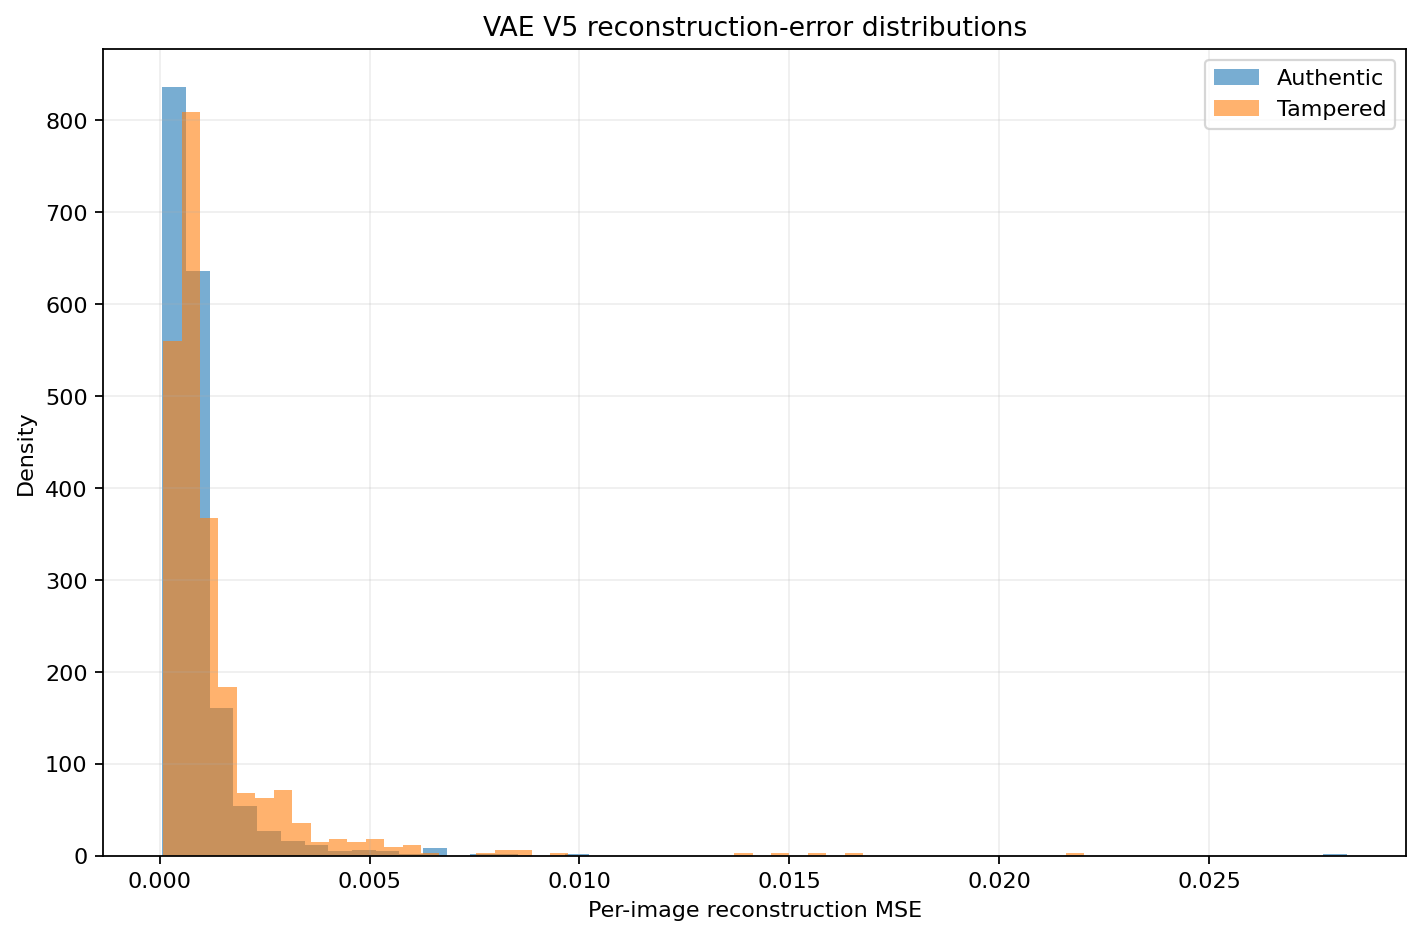

In [12]:
# 18. Forensic reconstruction-error distributions
per_image = pd.read_csv(PROJECT_ROOT / "results" / "vae_v5_test_per_image_metrics.csv")
display(per_image.groupby("class_name")["mse"].agg(["count", "mean", "median", "std"]))
image_path = PROJECT_ROOT / "outputs" / "vae_v5" / "authentic_vs_tampered_error.png"
display(Image.open(image_path))


Full-test reconstruction-MSE ROC-AUC: 0.604618
0.5 is approximately random ranking; higher indicates more separation.
The obtained ROC-AUC shows limited forensic separation.
VAE V5 is not a standalone tampering classifier or calibrated probability model.


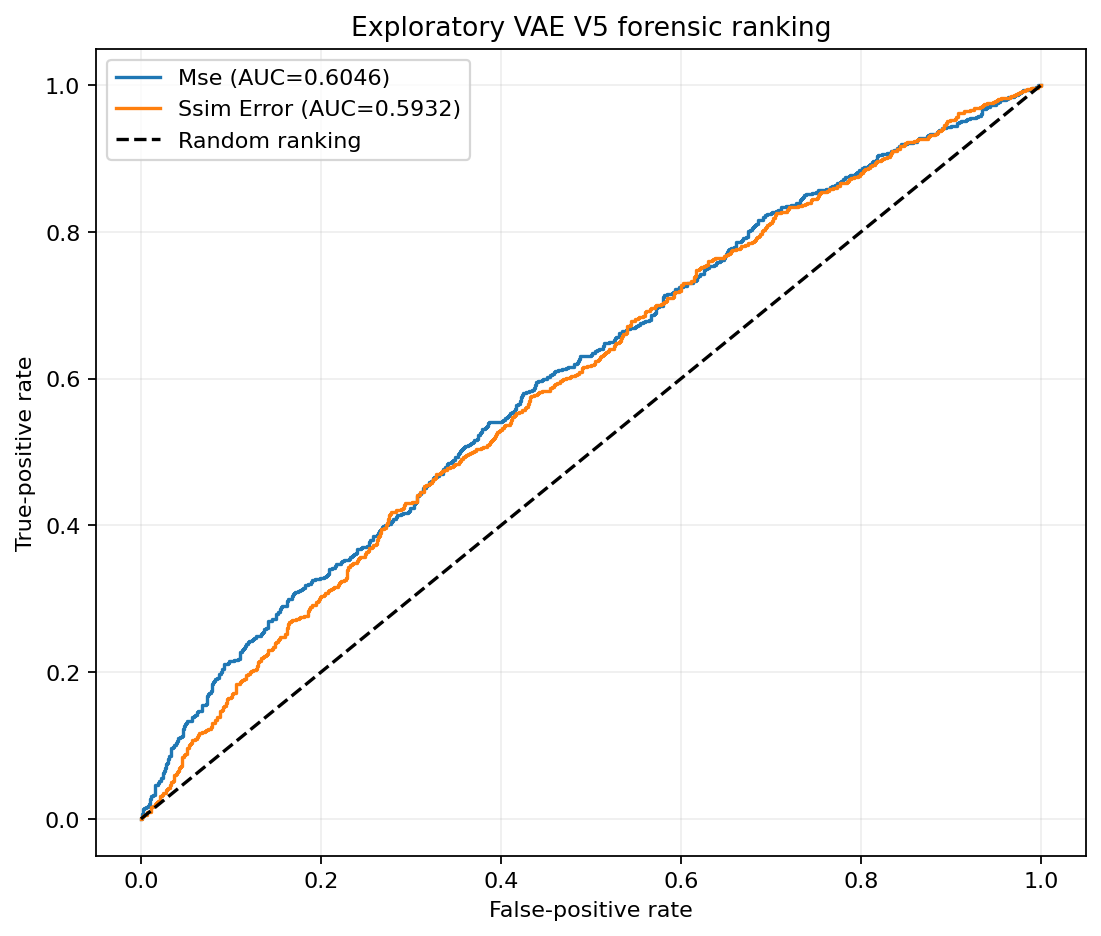

In [13]:
# 19. ROC-AUC using reconstruction MSE
mse_auc = metrics["roc_auc"]["mse"]
print(f"Full-test reconstruction-MSE ROC-AUC: {mse_auc:.6f}")
print("0.5 is approximately random ranking; higher indicates more separation.")
print("The obtained ROC-AUC shows limited forensic separation.")
print("VAE V5 is not a standalone tampering classifier or calibrated probability model.")
display(Image.open(PROJECT_ROOT / "outputs" / "vae_v5" / "roc_curves.png"))


In [14]:
# 20. Optional SSIM-error analysis
ssim_auc = metrics["roc_auc"]["ssim_error"]
ssim_group = per_image.groupby("class_name")["ssim"].agg(["mean", "median", "std"])
display(ssim_group)
print(f"SSIM-error ROC-AUC: {ssim_auc:.6f}")
print("SSIM error = 1 - SSIM; this remains an exploratory anomaly indicator.")


,mean,median,std
class_name,,,
authentic,0.952742,0.956793,0.021945
tampered,0.946442,0.951138,0.022989


SSIM-error ROC-AUC: 0.593219
SSIM error = 1 - SSIM; this remains an exploratory anomaly indicator.


In [15]:
# 21. Synthetic generation
with torch.no_grad():
    z = torch.randn(10, 256, device=DEVICE)
    synthetic = model.decode(z).cpu()
print("Note: prior-only generation has no encoder skips and may be visually degenerate.")
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for i, axis in enumerate(axes.flat):
    axis.imshow(synthetic[i].permute(1,2,0))
    axis.set_title(f"Synthetic {i+1}"); axis.axis("off")
plt.suptitle("Synthetic VAE V5 research output Ã¢â‚¬â€ not genuine forensic evidence")
plt.tight_layout()


Note: prior-only generation has no encoder skips and may be visually degenerate.


C:\Users\Chetanraje\AppData\Local\Temp\ipykernel_9484\3366653442.py:11: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()


In [16]:
# 22. Optional FID evaluation
RUN_FID = False
fid = metrics.get("fid")
if RUN_FID:
    print("Run src/evaluate_vae.py --run-fid on a suitable GPU, then reload this notebook.")
elif fid is None:
    print("FID: N/A Ã¢â‚¬â€ the source V5 notebook did not calculate a valid final V5 FID.")
    print("No V2 FID is reused and no value is invented.")
else:
    print("VAE V5 FID:", fid)


FID: N/A Ã¢â‚¬â€ the source V5 notebook did not calculate a valid final V5 FID.
No V2 FID is reused and no value is invented.


# 23. Interpretation

- VAE V5 substantially improves reconstruction over the previous project VAE.
- It defines a probabilistic latent and sampling path, but the current prior-only samples are visually degenerate because the decoder relies strongly on image skips.
- Authentic-only reconstruction training allows reconstruction behavior to be studied as an anomaly signal.
- MSE ROC-AUC near 0.60 shows only limited ranking separation because the distributions overlap.
- Therefore VAE V5 is a **forensic reconstruction and anomaly-analysis module**, not a standalone forgery classifier.

# 24. Limitations

CASIA is the primary dataset; cross-dataset generalization is untested. Reconstruction error and SSIM error are not tampering probabilities. The skip-connected decoder can rely strongly on image features, and prior generation has no image skip features, so reconstruction and generation quality must be evaluated separately. A valid V5 FID remains pending. All outputs are academic research artifacts.

# 25. Conclusion

VAE V5 provides substantially improved image reconstruction while preserving a probabilistic latent space. Authentic-only training yields useful exploratory anomaly signals, but the current ROC-AUC shows that reconstruction error alone is insufficient for reliable tampering detection. Reconstructed and generated outputs must not be treated as genuine forensic evidence.